# M1 Notebook 07 — Singular Value Decomposition, PCA, and Dimensionality Reduction

**Notebook ID:** M1_N07  
**Status:** Runnable first edition  
**Random seed:** 42

> SVD reveals the dominant directions linking a matrix's input and output spaces. PCA uses that structure to compress data while preserving as much variation as possible.


## Dependency setup

Run this cell first. It verifies the standard scientific packages and loads the small controlled `srai_math` wheel without reinstalling the scientific stack.


In [1]:
# Fast portable bootstrap for VS Code and Google Colab
from importlib.util import find_spec
from pathlib import Path
import importlib
import subprocess
import sys

PACKAGE_DIR = Path.home() / '.srai_notebook_packages' / '1.1.1rc1'
PACKAGE_DIR.mkdir(parents=True, exist_ok=True)
if str(PACKAGE_DIR) not in sys.path:
    sys.path.insert(0, str(PACKAGE_DIR))

required = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}
missing = [package for module, package in required.items() if find_spec(module) is None]
if missing:
    print('Installing missing standard dependencies:', ', '.join(missing))
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--upgrade',
        '--target', str(PACKAGE_DIR), *missing
    ])
    importlib.invalidate_caches()

if find_spec('srai_math') is None:
    wheel_name = 'srai_math-1.1.1rc1-py3-none-any.whl'
    local_candidates = [
        Path.cwd() / wheel_name,
        Path.cwd() / 'wheels' / wheel_name,
        Path.home() / 'Downloads' / wheel_name,
    ]
    local_wheel = next((path for path in local_candidates if path.is_file()), None)
    wheel_source = str(local_wheel) if local_wheel else (
        'https://raw.githubusercontent.com/mbayekebe/'
        'srai-book-01-mathematical-foundations/main/'
        'production-units/PU-B01-C06/wheels/' + wheel_name
    )
    print('Installing the controlled srai_math wheel...')
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--upgrade', '--no-deps',
        '--target', str(PACKAGE_DIR), wheel_source
    ])
    importlib.invalidate_caches()

import srai_math
print('Dependencies ready. srai_math version:', srai_math.__version__)


Dependencies ready. srai_math version: 1.1.1rc1


## 1. Learning objectives

1. State and verify the singular value decomposition.
2. Interpret singular values as directional strengths.
3. Construct rank-$k$ approximations.
4. Measure reconstruction error.
5. Derive PCA from centered data and SVD.
6. Interpret explained variance.
7. Apply dimensionality reduction to statistics, AI, and Decision Intelligence.


In [2]:
from srai_math.utils import environment_info, set_seed
from srai_math.algebra import (
    explained_variance_ratio_from_singular_values,
    frobenius_error,
    pca_fit_transform,
    pca_inverse_transform,
    rank_k_approximation,
    reconstruct_from_svd,
    svd_decomposition,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
set_seed(42)
environment_info()


EnvironmentInfo(python='3.12.13', platform='Linux-6.18.35-x86_64-with-glibc2.39', numpy='2.3.5')

## 2. Singular value decomposition

For any real matrix $A\in\mathbb R^{m\times n}$,

$$
A=U\Sigma V^\top,
$$

where:

- columns of $U$ are left singular vectors;
- columns of $V$ are right singular vectors;
- diagonal entries of $\Sigma$ are nonnegative singular values.


In [3]:
A = np.array([
    [3.0, 1.0],
    [1.0, 3.0],
])

U, s, Vt = svd_decomposition(A)
A_reconstructed = reconstruct_from_svd(U, s, Vt)

assert np.allclose(A_reconstructed, A)
U, s, Vt


(array([[-0.70710678, -0.70710678],
       [-0.70710678,  0.70710678]]), array([4., 2.]), array([[-0.70710678, -0.70710678],
       [-0.70710678,  0.70710678]]))

## 3. Orthogonality checks

In [4]:
assert np.allclose(U.T @ U, np.eye(U.shape[1]))
assert np.allclose(Vt @ Vt.T, np.eye(Vt.shape[0]))
print("Orthogonality verified.")


Orthogonality verified.


## 4. Geometric interpretation

The SVD decomposes a linear transformation into:

1. a rotation or reflection by $V^\top$;
2. axis-aligned scaling by $\Sigma$;
3. a rotation or reflection by $U$.


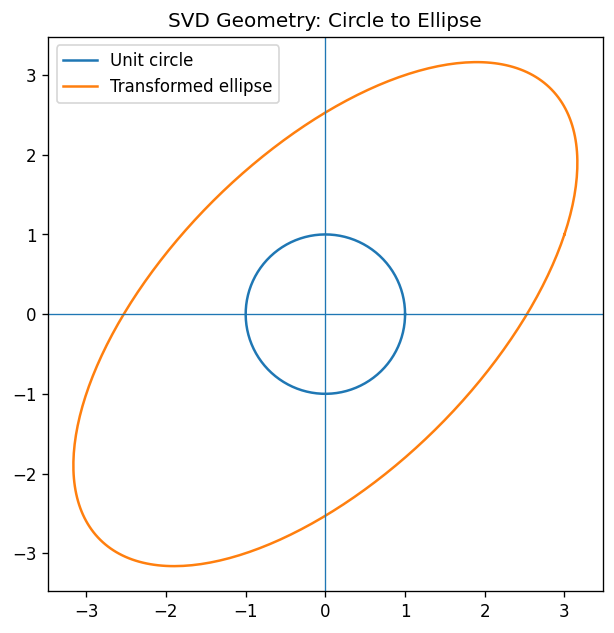

In [5]:
theta = np.linspace(0, 2*np.pi, 300)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
ellipse = circle @ A.T

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(circle[:, 0], circle[:, 1], label="Unit circle")
ax.plot(ellipse[:, 0], ellipse[:, 1], label="Transformed ellipse")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_aspect("equal")
ax.set_title("SVD Geometry: Circle to Ellipse")
ax.legend()
plt.show()


## 5. Rank-$k$ approximation

The truncated SVD

$$
A_k=U_k\Sigma_kV_k^\top
$$

is the best rank-$k$ approximation to $A$ in Frobenius norm.


In [6]:
A1 = rank_k_approximation(A, 1)
A2 = rank_k_approximation(A, 2)

errors = {
    "rank_1_error": frobenius_error(A, A1),
    "rank_2_error": frobenius_error(A, A2),
}
errors


{'rank_1_error': 2.0, 'rank_2_error': 1.2008898127460164e-15}

In [7]:
assert errors["rank_2_error"] <= errors["rank_1_error"]
assert np.isclose(errors["rank_2_error"], 0.0)
print("Rank-k approximation behavior verified.")


Rank-k approximation behavior verified.


## 6. Singular-value energy

The proportion associated with singular value $\sigma_i$ is

$$
\frac{\sigma_i^2}{\sum_j \sigma_j^2}.
$$


In [8]:
energy_ratio = explained_variance_ratio_from_singular_values(s)
pd.DataFrame({
    "singular_value": s,
    "energy_ratio": energy_ratio,
    "cumulative_ratio": np.cumsum(energy_ratio),
})


,singular_value,energy_ratio,cumulative_ratio
0,4.0,0.8,0.8
1,2.0,0.2,1.0


## 7. PCA from SVD

For centered data matrix $X_c$,

$$
X_c=U\Sigma V^\top.
$$

The rows of $V^\top$ are principal directions. The scores are

$$
Z=U\Sigma.
$$


In [9]:
X = np.array([
    [2.0, 1.0],
    [3.0, 2.0],
    [4.0, 2.5],
    [5.0, 4.0],
    [6.0, 4.5],
])

scores, components, explained, mean = pca_fit_transform(X, 2)
X_full = pca_inverse_transform(scores, components, mean)

assert np.allclose(X_full, X)

pd.DataFrame({
    "principal_component": ["PC1", "PC2"],
    "explained_variance_ratio": explained,
})


,principal_component,explained_variance_ratio
0,PC1,0.993992
1,PC2,0.006008


## 8. One-component reconstruction

In [10]:
scores_1, components_1, explained_1, mean_1 = pca_fit_transform(X, 1)
X_1 = pca_inverse_transform(scores_1, components_1, mean_1)

reconstruction_error = frobenius_error(X, X_1)
reconstruction_error


0.3315874264443549

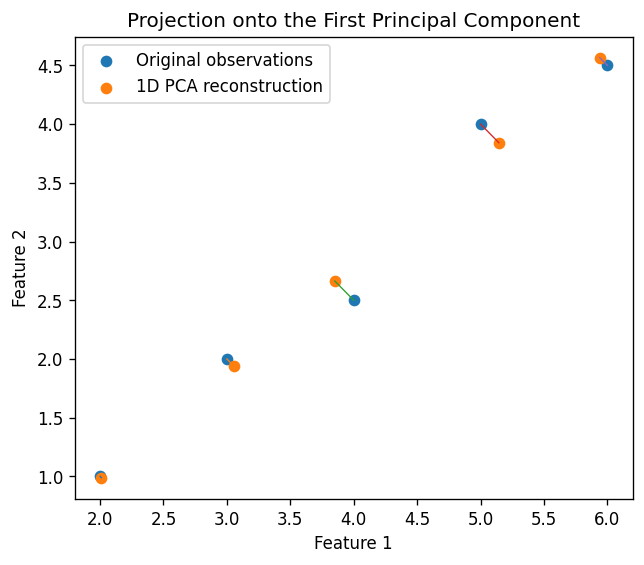

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], label="Original observations")
ax.scatter(X_1[:, 0], X_1[:, 1], label="1D PCA reconstruction")

for original, reconstructed in zip(X, X_1):
    ax.plot(
        [original[0], reconstructed[0]],
        [original[1], reconstructed[1]],
        linewidth=0.8,
    )

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Projection onto the First Principal Component")
ax.legend()
plt.show()


## 9. Independent NumPy verification

Verify the PCA explained-variance ratios from the eigenvalues of the centered covariance matrix. This avoids making scikit-learn a runtime requirement.


In [12]:
X_centered = X - X.mean(axis=0)
covariance = np.cov(X_centered, rowvar=False)
eigenvalues = np.linalg.eigvalsh(covariance)[::-1]
numpy_explained = eigenvalues / eigenvalues.sum()

difference = np.abs(numpy_explained - explained)
assert np.allclose(numpy_explained, explained, rtol=1e-10, atol=1e-12)

pd.DataFrame({
    'principal_component': ['PC1', 'PC2'],
    'srai_ratio': explained,
    'numpy_ratio': numpy_explained,
    'absolute_difference': difference,
})


,principal_component,srai_ratio,numpy_ratio,absolute_difference
0,PC1,0.993992,0.993992,0.000000e+00
1,PC2,0.006008,0.006008,9.540979e-18


Principal-component signs may differ between implementations because an eigenvector and its negative define the same direction.


## 10. Image-style compression experiment

In [13]:
grid = np.zeros((20, 20))
grid[3:17, 4:7] = 1.0
grid[3:6, 4:16] = 1.0
grid[9:12, 4:14] = 1.0
grid[14:17, 4:16] = 1.0

ranks = [1, 2, 4, 8]
compression_errors = []

for k in ranks:
    approximation = rank_k_approximation(grid, k)
    compression_errors.append(frobenius_error(grid, approximation))

pd.DataFrame({
    "rank": ranks,
    "frobenius_error": compression_errors,
})


,rank,frobenius_error
0,1,3.751076e+00
1,2,1.860544e+00
2,4,6.090450e-15
3,8,6.090450e-15


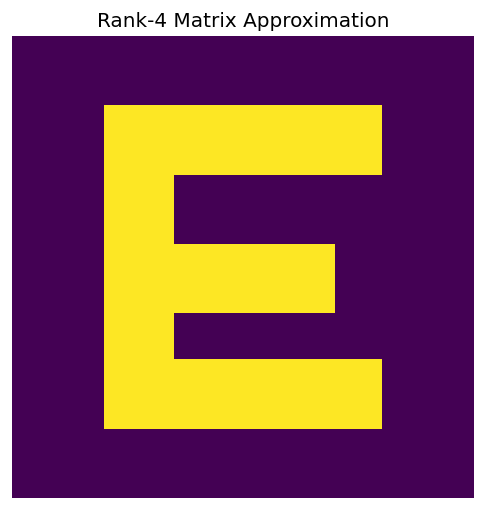

In [14]:
approximation = rank_k_approximation(grid, 4)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(approximation)
ax.set_title("Rank-4 Matrix Approximation")
ax.axis("off")
plt.show()


## 11. Statistics interpretation

PCA transforms correlated variables into orthogonal components ordered by explained variance. It is useful for compression and exploration, but principal components are not automatically causal or substantively meaningful.


## 12. AI interpretation

SVD and PCA support:

- latent semantic analysis;
- embedding compression;
- recommender systems;
- low-rank adaptation;
- denoising;
- model compression;
- visualization of high-dimensional representations.


## 13. Decision Intelligence case — Compressing national indicators

Suppose several national indicators are correlated. PCA can summarize shared variation into a smaller number of composite directions.


In [15]:
indicators = pd.DataFrame({
    "Agricultural_output": [105, 110, 96, 115, 101, 108],
    "Food_availability": [102, 108, 94, 112, 99, 106],
    "Electricity_access": [72, 75, 65, 80, 70, 74],
    "Health_capacity": [68, 71, 63, 76, 67, 70],
    "Transport_reliability": [66, 70, 61, 75, 65, 69],
})

standardized = (indicators - indicators.mean()) / indicators.std(ddof=0)
di_scores, di_components, di_explained, di_mean = pca_fit_transform(
    standardized.to_numpy(),
    2,
)

pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": di_explained,
})


,component,explained_variance_ratio
0,PC1,0.991745
1,PC2,0.006429


In [16]:
loadings = pd.DataFrame(
    di_components.T,
    index=indicators.columns,
    columns=["PC1", "PC2"],
)
loadings


,PC1,PC2
Agricultural_output,0.447338,-0.454233
Food_availability,0.446308,-0.587858
Electricity_access,0.448009,0.147702
Health_capacity,0.446741,0.563425
Transport_reliability,0.447670,0.329896


### Interpretation

The loadings describe mathematical directions of shared variation. Naming them requires domain expertise. PCA should not be used to hide policy trade-offs or replace transparent indicator reporting.


## 14. Engineering notes

- SVD is numerically stable but can be expensive for very large matrices.
- Randomized and truncated SVD methods are useful at scale.
- Variables should usually be centered before PCA.
- Standardization is appropriate when scales differ materially.
- Component signs are arbitrary.
- Missing data require explicit treatment before standard PCA.


## 15. Common errors

- Applying PCA without centering.
- Mixing incompatible measurement scales.
- Treating explained variance as causal importance.
- Retaining too few components solely for visual simplicity.
- Assuming PCA works well for strongly nonlinear manifolds.
- Ignoring interpretability and governance requirements.


## 16. Exercises

### Level A
Explain the difference between eigenvalues and singular values.

### Level B
Verify the SVD reconstruction formula.

### Level C
Implement a rank-$k$ approximation and compare errors.

### Capstone
Reduce a documented national-indicator dataset, justify preprocessing, select the number of components, interpret loadings, and explain what information is lost.


## 17. Key insight

SVD exposes the strongest input-output directions in a matrix. PCA applies this structure to centered data, compressing many variables into a smaller set of orthogonal directions while quantifying the variation retained and lost.
